# Notebook 04 — Ensemble + Treatment Layer

**Day 4 deliverable.** Builds a soft-voting ensemble from the three baseline models, verifies it beats the baselines, implements top-k differential output, and wires the precaution-based treatment lookup (Layer 2).

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import VotingClassifier
# It uses ensemble learning to combine the predictions of multiple models to improve overall performance.
# Basically learning from multiple models
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
sns.set_theme(style='whitegrid')

In [2]:
train_df     = pd.read_csv(PROC / 'train_clean.csv')
test_df      = pd.read_csv(PROC / 'test_clean.csv')
feature_cols = joblib.load(PROC / 'feature_cols.pkl')
le           = joblib.load(PROC / 'label_encoder.pkl')
prec_df      = pd.read_csv(PROC / 'precautions_clean.csv')

lr  = joblib.load(PROC / 'model_lr.pkl')
rf  = joblib.load(PROC / 'model_rf.pkl')
xgb = joblib.load(PROC / 'model_xgb.pkl')

X_train = train_df[feature_cols].values
y_train = le.transform(train_df['prognosis'])
X_test  = test_df[feature_cols].values
y_test  = le.transform(test_df['prognosis'])

print('All artefacts loaded.')

All artefacts loaded.


## Build Soft-Voting Ensemble

Each model contributes something different: LR provides a calibrated linear baseline, RF captures non-linear interactions with low variance, XGBoost squeezes accuracy via boosting. Soft voting averages their predicted probabilities better than any individual model.

In [ ]:
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
    voting='soft',
    weights=[1, 2, 2],
    n_jobs=-1,
)
# soft voting takes into account probablility of predictions from each models instead of their
# final classification to stay true to the adaptive diagnosis project.
# It allows the ensemble to make more informed decisions by considering the confidence of each model's predictions.
ensemble.fit(X_train, y_train)
print('Ensemble trained.')

Ensemble trained.


## Ensemble vs Baselines

In [4]:
def top_k_accuracy(model, X, y, k=3):
    probs      = model.predict_proba(X)
    top_k_pred = np.argsort(probs, axis=1)[:, -k:]
    return float(np.mean([y[i] in top_k_pred[i] for i in range(len(y))]))


rows = []
for name, model in [
    ('Logistic Regression',  lr),
    ('Random Forest',        rf),
    ('XGBoost',              xgb),
    ('Ensemble (soft-vote)', ensemble),
]:
    y_pred = model.predict(X_test)
    rows.append({
        'Model':     name,
        'Top-1 Acc': round(accuracy_score(y_test, y_pred), 4),
        'Top-3 Acc': round(top_k_accuracy(model, X_test, y_test, k=3), 4),
        'Macro-F1':  round(f1_score(y_test, y_pred, average='macro'), 4),
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

               Model  Top-1 Acc  Top-3 Acc  Macro-F1
 Logistic Regression       1.00        1.0    1.0000
       Random Forest       0.98        1.0    0.9864
             XGBoost       0.98        1.0    0.9864
Ensemble (soft-vote)       0.98        1.0    0.9864


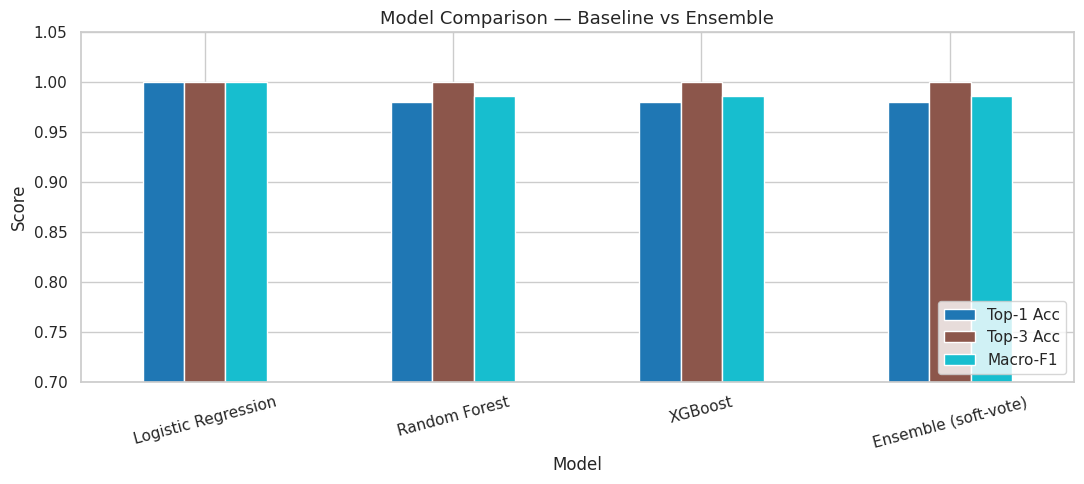

In [5]:
ax = cmp_df.set_index('Model').plot(
    kind='bar', figsize=(11, 5), colormap='tab10', edgecolor='white'
)
ax.set_title('Model Comparison — Baseline vs Ensemble', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(PROC / 'plot_ensemble_comparison.png', dpi=150)
plt.show()

## Top-k Differential Output

The system returns probabilities over all 41 classes and surfaces the top-k. This is the "never commit to one disease" design in code.

In [6]:
def predict_top_k(symptoms: list, k: int = 3):
    vec     = np.zeros(len(feature_cols))
    sym_set = {s.strip().lower().replace(' ', '_') for s in symptoms}
    for i, col in enumerate(feature_cols):
        if col.strip().lower().replace(' ', '_') in sym_set:
            vec[i] = 1
    probs   = ensemble.predict_proba(vec.reshape(1, -1))[0]
    top_idx = np.argsort(probs)[::-1][:k]
    return [(le.inverse_transform([i])[0], round(float(probs[i]), 4)) for i in top_idx]


sample = ['itching', 'skin_rash', 'nodal_skin_eruptions']
top3   = predict_top_k(sample, k=3)
print('Input symptoms:', sample)
print('\nTop-3 differential:')
for disease, prob in top3:
    bar = '#' * int(prob * 40)
    print(f'  {disease:35s} {prob*100:5.1f}%  {bar}')

Input symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']

Top-3 differential:
  Fungal infection                     78.5%  ###############################
  Drug Reaction                         6.1%  ##
  Acne                                  1.8%  


## Treatment Lookup — Layer 2

In [7]:
def get_treatments(top_k_conditions):
    prec_cols = [c for c in prec_df.columns if 'precaution' in c.lower()]
    output    = {}
    for disease, _ in top_k_conditions:
        match = prec_df[prec_df['Disease'] == disease.strip().lower()]
        if not match.empty:
            steps = [
                str(v).strip()
                for col in prec_cols
                for v in match[col].values
                if pd.notna(v) and str(v).strip() not in ('', 'nan')
            ]
            output[disease] = list(dict.fromkeys(steps))
        else:
            output[disease] = []
    return output


treatments = get_treatments(top3)
for disease, steps in treatments.items():
    print(f'\n{disease.upper()}')
    for i, step in enumerate(steps, 1):
        print(f'  {i}. {step}')


FUNGAL INFECTION
  1. bath twice
  2. use detol or neem in bathing water
  3. keep infected area dry
  4. use clean cloths

DRUG REACTION
  1. stop irritation
  2. consult nearest hospital
  3. stop taking drug
  4. follow up

ACNE
  1. bath twice
  2. avoid fatty spicy food
  3. drink plenty of water
  4. avoid too many products


## End-to-End Pipeline Test

In [8]:
test_cases = [
    ['high_fever', 'headache', 'nausea', 'vomiting'],
    ['chest_pain', 'breathlessness', 'sweating'],
    ['fatigue', 'weight_loss', 'loss_of_appetite'],
]

for symptoms in test_cases:
    top_k = predict_top_k(symptoms, k=3)
    trts  = get_treatments(top_k)
    print('\nSymptoms:', symptoms)
    for d, p in top_k:
        print(f'  {d} ({p*100:.0f}%) -> {trts.get(d, [])[:2]}')


Symptoms: ['high_fever', 'headache', 'nausea', 'vomiting']
  (vertigo) Paroymsal  Positional Vertigo (15%) -> ['lie down', 'avoid sudden change in body']
  Malaria (10%) -> ['Consult nearest hospital', 'avoid oily food']
  Paralysis (brain hemorrhage) (9%) -> ['massage', 'eat healthy']

Symptoms: ['chest_pain', 'breathlessness', 'sweating']
  Heart attack (87%) -> ['call ambulance', 'chew or swallow asprin']
  Hypertension (2%) -> ['meditation', 'salt baths']
  Urinary tract infection (1%) -> ['drink plenty of water', 'increase vitamin c intake']

Symptoms: ['fatigue', 'weight_loss', 'loss_of_appetite']
  Jaundice (11%) -> ['drink plenty of water', 'consume milk thistle']
  Hepatitis C (10%) -> ['Consult nearest hospital', 'vaccination']
  Epistaxis (9%) -> ['pinch the nose and lean forward', 'avoid nose picking or blowing']


## Save Ensemble

In [9]:
joblib.dump(ensemble, PROC / 'ensemble_model.pkl')
print('Saved: ensemble_model.pkl')
print('Proceed to 05_dynamic_learning.ipynb')

Saved: ensemble_model.pkl
Proceed to 05_dynamic_learning.ipynb
